<a href="https://colab.research.google.com/github/1ZeroStorm/Pendulum-Spring-Experiment/blob/main/Physics_experiment_pendulum_and_spring_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proving gravitational force from pendulum experiment

In [19]:
import pandas as pd

data_pendulum = {
    "No.": [1, 2, 3, 4, 5],
    "time_1 (s)": [11.0, 10.8, 9.2, 7.2, 6.2],
    "time_2 (s)": [11.0, 10.2, 9.0, 7.8, 6.2],
    "time_3 (s)": [11.0, 10.8, 9.0, 7.4, 6.2],
    "t_avg (s)": [11, 10.6, 9.06, 7.46, 6.2],
    "T (s)": [1.1, 1.06, 0.906, 0.746, 0.62],
    "T² (s^2)": [1.21, 1.12, 0.82, 0.55, 0.38],
    "l (m)": [0.275, 0.245, 0.176, 0.106, 0.074]
}

df_pendulum = pd.DataFrame(data_pendulum)
df_pendulum


,No.,time_1 (s),time_2 (s),time_3 (s),t_avg (s),T (s),T² (s^2),l (m)
0,1,11.0,11.0,11.0,11.00,1.100,1.21,0.275
1,2,10.8,10.2,10.8,10.60,1.060,1.12,0.245
2,3,9.2,9.0,9.0,9.06,0.906,0.82,0.176
3,4,7.2,7.8,7.4,7.46,0.746,0.55,0.106
4,5,6.2,6.2,6.2,6.20,0.620,0.38,0.074


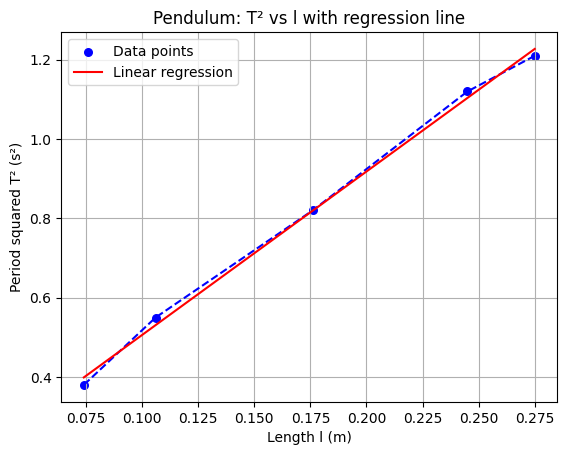

Regression equation: T² = 4.121 * l + 0.094
R² = 0.997


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Data
data_pendulum = {
    "No.": [1, 2, 3, 4, 5],
    "time_1 (s)": [11.0, 10.8, 9.2, 7.2, 6.2],
    "time_2 (s)": [11.0, 10.2, 9.0, 7.8, 6.2],
    "time_3 (s)": [11.0, 10.8, 9.0, 7.4, 6.2],
    "t_avg (s)": [11, 10.6, 9.06, 7.46, 6.2],
    "T (s)": [1.1, 1.06, 0.906, 0.746, 0.62],
    "T² (s^2)": [1.21, 1.12, 0.82, 0.55, 0.38],
    "l (m)": [0.275, 0.245, 0.176, 0.106, 0.074]
}

df_pendulum = pd.DataFrame(data_pendulum)

# Independent (X) and dependent (y)
X = df_pendulum["l (m)"].values.reshape(-1, 1)
y = df_pendulum["T² (s^2)"].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Plot
plt.plot(X, y, color="blue", linestyle = '--')
plt.scatter(X, y, color="blue", label="Data points", s = 30)
plt.plot(X, y_pred, color="red", label="Linear regression")

plt.xlabel("Length l (m)")
plt.ylabel("Period squared T² (s²)")
plt.title("Pendulum: T² vs l with regression line")
plt.legend()
plt.grid(True)
plt.show()

# Print regression equation and R²
print(f"Regression equation: T² = {model.coef_[0]:.3f} * l + {model.intercept_:.3f}")
print(f"R² = {model.score(X, y):.3f}")


In [21]:
import math

# taking a random point(X)
l_1 = 0.1
l_2 = 0.2
delta_l2 = l_2 - l_1

# taking a random point (y)
T_1 = model.predict([[l_1]])[0]
T_2 = model.predict([[l_2]])[0]
delta_T_squared = T_2 - T_1

# subtituing in g
g = 4 * (math.pi)**2 * delta_l2/delta_T_squared

# printing
print(f"with the l_1: {l_1}, the T_1: {T_1}")
print(f"with the l_2: {l_2}, the T_2: {T_2}")
print("\n")
print("ΔL =", delta_l2)
print("ΔT² =", delta_T_squared)
print(f"\033[92mgravitational force = {g}\033[0m")

with the l_1: 0.1, the T_1: 0.5060771260564986
with the l_2: 0.2, the T_2: 0.9182086073643466


ΔL = 0.1
ΔT² = 0.41213148130784805
gravitational force = 9.579083228264334


--------------------------------------------------------------

# Proving gravitational force from spring experiment

In [22]:
data_spring = {
    "No": [1, 2, 3, 4, 5],
    "m (kg)": [0.05, 0.07, 0.09, 0.10, 0.12],
    "l (m)": [0.182, 0.200, 0.220, 0.229, 0.245],
    "Δl (m)": [0.039, 0.057, 0.077, 0.086, 0.102],
    "t₁ (s)": [4.4, 5.0, 5.8, 6.0, 6.4],
    "t₂ (s)": [4.0, 4.8, 5.6, 5.6, 6.5],
    "t₃ (s)": [4.6, 5.0, 5.8, 6.0, 6.4],
    "t_avg (s)": [4.33, 4.93, 5.73, 5.86, 6.43],
    "T (s)": [0.43, 0.493, 0.573, 0.585, 0.643],
    "T² (s²)": [0.18, 0.24, 0.328, 0.34, 0.41]
}

df_spring = pd.DataFrame(data_spring)
df_spring


,No,m (kg),l (m),Δl (m),t₁ (s),t₂ (s),t₃ (s),t_avg (s),T (s),T² (s²)
0,1,0.05,0.182,0.039,4.4,4.0,4.6,4.33,0.430,0.180
1,2,0.07,0.200,0.057,5.0,4.8,5.0,4.93,0.493,0.240
2,3,0.09,0.220,0.077,5.8,5.6,5.8,5.73,0.573,0.328
3,4,0.10,0.229,0.086,6.0,5.6,6.0,5.86,0.585,0.340
4,5,0.12,0.245,0.102,6.4,6.5,6.4,6.43,0.643,0.410


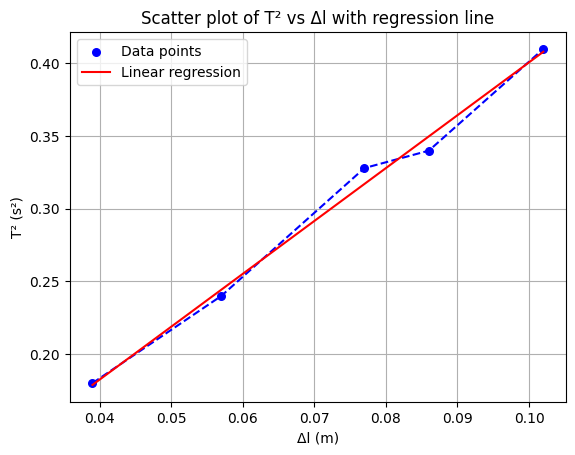

Regression equation: T² = 3.639 * Δl + 0.037


In [23]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Independent (X) and dependent (y) variables
X = df_spring["Δl (m)"].values.reshape(-1, 1)
y = df_spring["T² (s²)"].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Plot
plt.plot(X, y, color="blue", linestyle = '--')
plt.scatter(X, y, color="blue", label="Data points", s = 30)
plt.plot(X, y_pred, color="red", label="Linear regression")

plt.xlabel("Δl (m)")
plt.ylabel("T² (s²)")
plt.title("Scatter plot of T² vs Δl with regression line")
plt.legend()
plt.grid(True)
plt.show()

# Print regression equation
print(f"Regression equation: T² = {model.coef_[0]:.3f} * Δl + {model.intercept_:.3f}")


In [24]:
import math

# taking a random point(X)
l_1 = 0.05
l_2 = 0.06
delta_l2 = l_2 - l_1

# taking a random point (y)
T_1 = model.predict([[l_1]])[0]
T_2 = model.predict([[l_2]])[0]
delta_T_squared = T_2 - T_1

# subtituing in g
g = 4 * (math.pi)**2 * delta_l2/delta_T_squared

# printing
print(f"with the l_1: {l_1}, the T_1: {T_1}")
print(f"with the l_2: {l_2}, the T_2: {T_2}")
print("\n")
print("ΔL =", delta_l2)
print("ΔT² =", delta_T_squared)
print(f"\033[92mgravitational force = {g}\033[0m")

with the l_1: 0.05, the T_1: 0.21881271562345983
with the l_2: 0.06, the T_2: 0.255203384261541


ΔL = 0.009999999999999995
ΔT² = 0.03639066863808116
gravitational force = 10.848500201242542
